# Waste Classification: Baseline CNN vs EfficientNet-B0
## Comparing a Custom CNN with Transfer Learning using EfficientNet-B0

**Pipeline:**
1. Data Loading & Preprocessing (resize 224×224, normalization, augmentation)
2. Dataset Splitting (70% train / 15% val / 15% test)
3. Baseline CNN (3 Conv blocks + FC layers)
4. EfficientNet-B0 (pretrained, fine-tuned)
5. Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix)
6. Error Analysis & Model Comparison

In [1]:
# ===================== IMPORTS & SETUP =====================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split
from PIL import Image
from collections import Counter
import time, copy, warnings, os
warnings.filterwarnings('ignore')

# ---- Use GPU for faster training ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
Memory: 8.6 GB


---
## 1. Data Loading & Preprocessing

In [2]:
# ===================== DATA TRANSFORMS =====================
DATA_DIR = 'Datset/standardized_256'
IMG_SIZE = 224
BATCH_SIZE = 32

# Training transform: with data augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transform: no augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Custom dataset that applies different transforms per split
class WasteSubset(Dataset):
    """Subset of ImageFolder with custom transform."""
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_path, label = self.dataset.samples[self.indices[idx]]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Load full dataset for splitting
full_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Total images: {len(full_dataset)}")

label_counts = Counter([label for _, label in full_dataset.samples])
for idx, name in enumerate(class_names):
    print(f"  {name}: {label_counts[idx]} images")

Number of classes: 10
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Total images: 12259
  battery: 756 images
  biological: 699 images
  cardboard: 1411 images
  clothes: 1892 images
  glass: 1736 images
  metal: 930 images
  paper: 1336 images
  plastic: 1597 images
  shoes: 1449 images
  trash: 453 images


In [3]:
# ===================== DATASET SPLITTING =====================
# 70% train, 15% validation, 15% test (stratified)
targets = [s[1] for s in full_dataset.samples]
indices = list(range(len(full_dataset)))

# Split: 70% train | 30% temp
train_idx, temp_idx = train_test_split(
    indices, test_size=0.3, random_state=42, stratify=targets)

# Split temp: 50/50 → 15% val | 15% test
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=temp_targets)

print(f"Training:   {len(train_idx)} ({len(train_idx)/len(full_dataset)*100:.1f}%)")
print(f"Validation: {len(val_idx)} ({len(val_idx)/len(full_dataset)*100:.1f}%)")
print(f"Test:       {len(test_idx)} ({len(test_idx)/len(full_dataset)*100:.1f}%)")

# Create datasets with appropriate transforms
train_dataset = WasteSubset(full_dataset, train_idx, train_transform)
val_dataset   = WasteSubset(full_dataset, val_idx, val_test_transform)
test_dataset  = WasteSubset(full_dataset, test_idx, val_test_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"\nBatches → Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Training:   8581 (70.0%)
Validation: 1839 (15.0%)
Test:       1839 (15.0%)

Batches → Train: 269, Val: 58, Test: 58


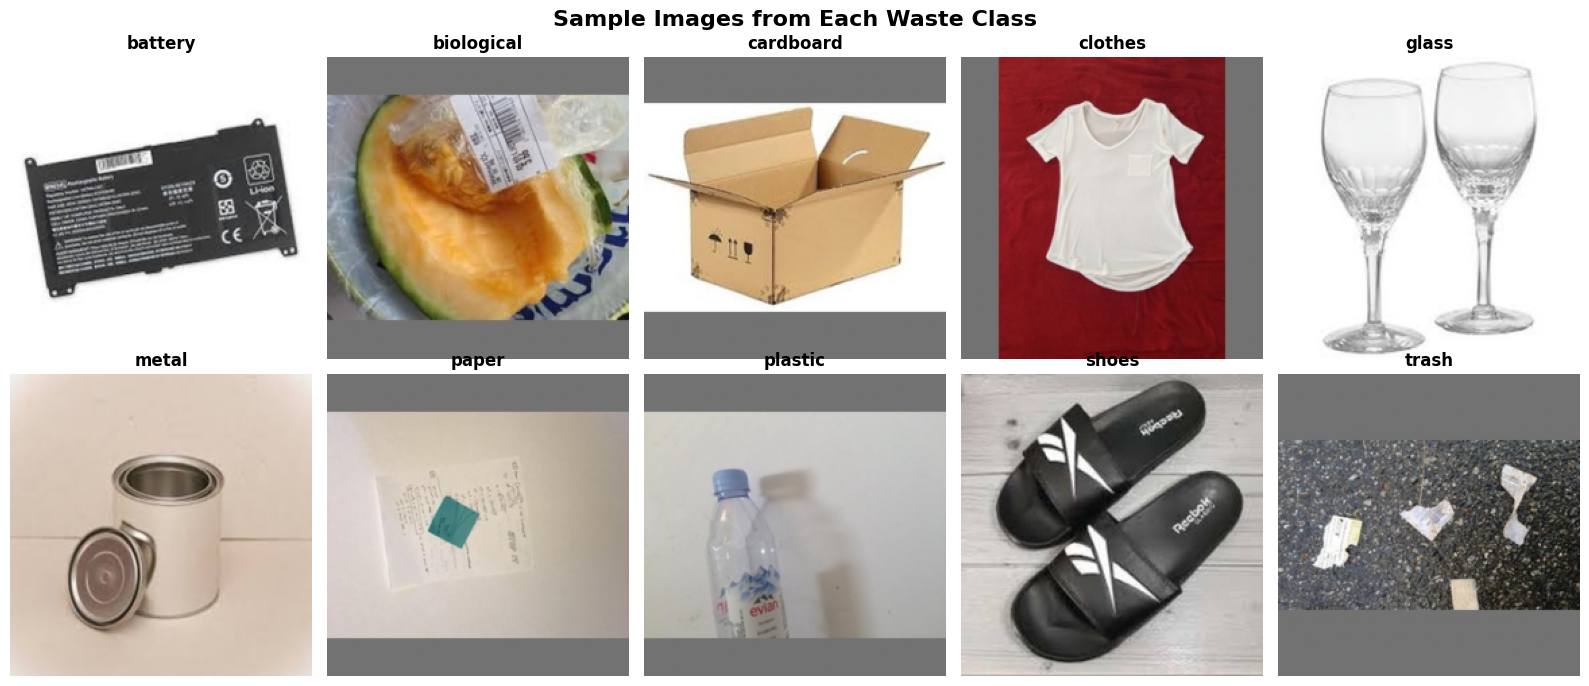

In [4]:
# ===================== VISUALIZE SAMPLES =====================
def denormalize(tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    t = tensor.clone()
    for ch, m, s in zip(t, mean, std):
        ch.mul_(s).add_(m)
    return torch.clamp(t, 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Images from Each Waste Class', fontsize=16, fontweight='bold')

for cls_idx in range(num_classes):
    cls_indices = [i for i, (_, lb) in enumerate(full_dataset.samples) if lb == cls_idx]
    img_path, _ = full_dataset.samples[cls_indices[0]]
    img = Image.open(img_path).convert('RGB')
    img_t = val_test_transform(img)
    img_show = denormalize(img_t)

    row, col = divmod(cls_idx, 5)
    axes[row, col].imshow(img_show.permute(1,2,0).numpy())
    axes[row, col].set_title(class_names[cls_idx], fontsize=12, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

---
## 2. Model Architectures

In [5]:
# ===================== BASELINE CNN =====================
class BaselineCNN(nn.Module):
    """
    Simple CNN with 3 convolutional blocks:
      Conv2d → BatchNorm → ReLU → MaxPool
    Followed by Global Average Pooling and FC classifier.
    Input: 224×224×3
    """
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()

        # Block 1: 3→32, 224→112
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Block 2: 32→64, 112→56
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Block 3: 64→128, 56→28
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Global Average Pooling → 128×1×1
        self.gap = nn.AdaptiveAvgPool2d(1)
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

baseline_cnn = BaselineCNN(num_classes=num_classes).to(device)
print("===== Baseline CNN =====")
print(baseline_cnn)
total_p = sum(p.numel() for p in baseline_cnn.parameters())
train_p = sum(p.numel() for p in baseline_cnn.parameters() if p.requires_grad)
print(f"\nTotal params: {total_p:,}  |  Trainable: {train_p:,}")

dummy = torch.randn(1, 3, 224, 224).to(device)
print(f"Output shape: {baseline_cnn(dummy).shape}")

===== Baseline CNN =====
BaselineCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=1)
  (clas

In [6]:
# ===================== EFFICIENTNET-B0 =====================
def create_efficientnet(num_classes, freeze_backbone=True):
    """
    EfficientNet-B0 with ImageNet pretrained weights.
    Replaces classifier for our number of classes.
    Optionally freezes backbone (feature extractor).
    """
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier head
    in_feat = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_feat, num_classes)
    )
    return model

efficientnet = create_efficientnet(num_classes, freeze_backbone=True).to(device)

total_p = sum(p.numel() for p in efficientnet.parameters())
train_p = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)
frozen_p = total_p - train_p
print("===== EfficientNet-B0 (frozen backbone) =====")
print(f"Total params:     {total_p:,}")
print(f"Trainable params: {train_p:,}")
print(f"Frozen params:    {frozen_p:,}")

dummy = torch.randn(1, 3, 224, 224).to(device)
print(f"Output shape: {efficientnet(dummy).shape}")

===== EfficientNet-B0 (frozen backbone) =====
Total params:     4,020,358
Trainable params: 12,810
Frozen params:    4,007,548
Output shape: torch.Size([1, 10])


---
## 3. Training

In [7]:
# ===================== TRAINING FUNCTION =====================
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, num_epochs=15, device=device):
    """
    Train model and track loss/accuracy for both train and val sets.
    Saves best model weights based on validation accuracy.
    """
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        t0 = time.time()

        # ---- Training ----
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for i, (imgs, labels) in enumerate(train_loader):
            if (i+1) % 50 == 0:
                print(f"    Batch {i+1}/{len(train_loader)}: {100.*(i+1)/len(train_loader):.1f}% done", end='\r')
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            _, pred = out.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
        print(' ' * 60, end='\r')
        tr_loss = run_loss / total
        tr_acc = 100. * correct / total

        # ---- Validation ----
        model.eval()
        run_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                loss = criterion(out, labels)
                run_loss += loss.item() * imgs.size(0)
                _, pred = out.max(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()
        vl_loss = run_loss / total
        vl_acc = 100. * correct / total

        if scheduler:
            scheduler.step()

        if vl_acc > best_acc:
            best_acc = vl_acc
            best_wts = copy.deepcopy(model.state_dict())

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        elapsed = time.time() - t0
        print(f"Epoch [{epoch+1:02d}/{num_epochs}]  "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}%  |  "
              f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.2f}%  |  "
              f"{elapsed:.1f}s")

    model.load_state_dict(best_wts)
    print(f"\nBest Val Accuracy: {best_acc:.2f}%")
    return model, history

In [8]:
# ===================== EVALUATION FUNCTION =====================
def evaluate_model(model, test_loader, class_names, device=device):
    """Evaluate on test set → accuracy, precision, recall, F1."""
    model.eval()
    all_preds, all_labels, all_imgs = [], [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            _, pred = out.max(1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_imgs.extend(imgs.cpu())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc  = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(all_labels, all_preds, average='weighted') * 100
    rec  = recall_score(all_labels, all_preds, average='weighted') * 100
    f1   = f1_score(all_labels, all_preds, average='weighted') * 100

    print(f"  Accuracy:  {acc:.2f}%")
    print(f"  Precision: {prec:.2f}%")
    print(f"  Recall:    {rec:.2f}%")
    print(f"  F1-Score:  {f1:.2f}%")
    print(f"\n{classification_report(all_labels, all_preds, target_names=class_names)}")

    metrics = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1}
    return all_preds, all_labels, all_imgs, metrics

In [9]:
# ===================== TRAIN BASELINE CNN =====================
print("=" * 60)
print("  TRAINING BASELINE CNN")
print("=" * 60)

baseline_cnn = BaselineCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(baseline_cnn.parameters(), lr=0.001)
scheduler_cnn = optim.lr_scheduler.StepLR(optimizer_cnn, step_size=10, gamma=0.1)

baseline_cnn, history_cnn = train_model(
    baseline_cnn, train_loader, val_loader,
    criterion, optimizer_cnn, scheduler_cnn,
    num_epochs=20, device=device
)

  TRAINING BASELINE CNN
Epoch [01/20]  Train Loss: 2.0124  Acc: 27.51%  |  Val Loss: 1.7906  Acc: 38.17%  |  125.0s
Epoch [02/20]  Train Loss: 1.8521  Acc: 34.66%  |  Val Loss: 1.9143  Acc: 32.90%  |  51.0s
Epoch [03/20]  Train Loss: 1.7846  Acc: 37.15%  |  Val Loss: 1.8704  Acc: 33.71%  |  48.9s
Epoch [04/20]  Train Loss: 1.7378  Acc: 38.69%  |  Val Loss: 1.5350  Acc: 46.98%  |  50.2s
Epoch [05/20]  Train Loss: 1.6837  Acc: 41.17%  |  Val Loss: 1.5048  Acc: 45.30%  |  47.8s
Epoch [06/20]  Train Loss: 1.6443  Acc: 42.10%  |  Val Loss: 1.4399  Acc: 50.03%  |  52.7s
Epoch [07/20]  Train Loss: 1.6158  Acc: 42.92%  |  Val Loss: 1.4752  Acc: 49.05%  |  49.3s
Epoch [08/20]  Train Loss: 1.5944  Acc: 43.97%  |  Val Loss: 1.4454  Acc: 49.16%  |  46.0s
Epoch [09/20]  Train Loss: 1.5632  Acc: 45.88%  |  Val Loss: 1.3972  Acc: 50.30%  |  46.0s
Epoch [10/20]  Train Loss: 1.5476  Acc: 45.48%  |  Val Loss: 1.3695  Acc: 52.96%  |  46.3s
Epoch [11/20]  Train Loss: 1.4877  Acc: 47.85%  |  Val Loss: 1.30

In [10]:
# ===================== TRAIN EFFICIENTNET - PHASE 1 =====================
# Phase 1: Train only the classifier head (backbone frozen)
print("=" * 60)
print("  EFFICIENTNET-B0 — PHASE 1: FROZEN BACKBONE")
print("=" * 60)

efficientnet = create_efficientnet(num_classes, freeze_backbone=True).to(device)
criterion = nn.CrossEntropyLoss()
opt_eff1 = optim.Adam(efficientnet.classifier.parameters(), lr=0.001)
sch_eff1 = optim.lr_scheduler.StepLR(opt_eff1, step_size=5, gamma=0.1)

efficientnet, hist_eff_p1 = train_model(
    efficientnet, train_loader, val_loader,
    criterion, opt_eff1, sch_eff1,
    num_epochs=10, device=device
)

  EFFICIENTNET-B0 — PHASE 1: FROZEN BACKBONE
Epoch [01/10]  Train Loss: 1.1085  Acc: 68.95%  |  Val Loss: 0.6399  Acc: 81.95%  |  49.6s
Epoch [02/10]  Train Loss: 0.6978  Acc: 78.62%  |  Val Loss: 0.5203  Acc: 84.56%  |  53.7s
Epoch [03/10]  Train Loss: 0.6206  Acc: 80.17%  |  Val Loss: 0.4963  Acc: 85.15%  |  44.8s
Epoch [04/10]  Train Loss: 0.5961  Acc: 80.68%  |  Val Loss: 0.4541  Acc: 85.86%  |  43.8s
Epoch [05/10]  Train Loss: 0.5743  Acc: 81.10%  |  Val Loss: 0.4569  Acc: 85.48%  |  47.3s
Epoch [06/10]  Train Loss: 0.5456  Acc: 82.04%  |  Val Loss: 0.4354  Acc: 86.51%  |  56.4s
Epoch [07/10]  Train Loss: 0.5502  Acc: 82.24%  |  Val Loss: 0.4552  Acc: 85.48%  |  55.2s
Epoch [08/10]  Train Loss: 0.5440  Acc: 82.61%  |  Val Loss: 0.4424  Acc: 85.86%  |  55.0s
Epoch [09/10]  Train Loss: 0.5380  Acc: 82.64%  |  Val Loss: 0.4500  Acc: 85.64%  |  56.9s
Epoch [10/10]  Train Loss: 0.5450  Acc: 81.98%  |  Val Loss: 0.4378  Acc: 85.64%  |  51.5s

Best Val Accuracy: 86.51%


In [11]:
# ===================== TRAIN EFFICIENTNET - PHASE 2 =====================
# Phase 2: Unfreeze last blocks and fine-tune with lower LR
print("=" * 60)
print("  EFFICIENTNET-B0 — PHASE 2: FINE-TUNING")
print("=" * 60)

# Unfreeze last 3 feature blocks (blocks 5, 6, 7)
for param in efficientnet.features[5:].parameters():
    param.requires_grad = True

train_p = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)
print(f"Trainable params after unfreezing: {train_p:,}")

# Use differential learning rates
opt_eff2 = optim.Adam([
    {'params': efficientnet.features[5:].parameters(), 'lr': 1e-4},
    {'params': efficientnet.classifier.parameters(),   'lr': 5e-4},
])
sch_eff2 = optim.lr_scheduler.StepLR(opt_eff2, step_size=5, gamma=0.1)

efficientnet, hist_eff_p2 = train_model(
    efficientnet, train_loader, val_loader,
    criterion, opt_eff2, sch_eff2,
    num_epochs=10, device=device
)

# Combine both phases' histories
history_eff = {k: hist_eff_p1[k] + hist_eff_p2[k] for k in hist_eff_p1}

  EFFICIENTNET-B0 — PHASE 2: FINE-TUNING
Trainable params after unfreezing: 3,711,698
Epoch [01/10]  Train Loss: 0.4325  Acc: 85.64%  |  Val Loss: 0.2907  Acc: 90.92%  |  58.6s
Epoch [02/10]  Train Loss: 0.2789  Acc: 90.88%  |  Val Loss: 0.2441  Acc: 92.06%  |  58.5s
Epoch [03/10]  Train Loss: 0.2038  Acc: 93.24%  |  Val Loss: 0.2277  Acc: 92.99%  |  58.3s
Epoch [04/10]  Train Loss: 0.1570  Acc: 94.72%  |  Val Loss: 0.2131  Acc: 92.93%  |  55.8s
Epoch [05/10]  Train Loss: 0.1181  Acc: 96.22%  |  Val Loss: 0.2152  Acc: 93.20%  |  58.8s
Epoch [06/10]  Train Loss: 0.0874  Acc: 97.18%  |  Val Loss: 0.2013  Acc: 94.51%  |  58.7s
Epoch [07/10]  Train Loss: 0.0775  Acc: 97.66%  |  Val Loss: 0.1986  Acc: 94.24%  |  56.7s
Epoch [08/10]  Train Loss: 0.0781  Acc: 97.38%  |  Val Loss: 0.1999  Acc: 94.24%  |  56.1s
Epoch [09/10]  Train Loss: 0.0720  Acc: 97.81%  |  Val Loss: 0.2082  Acc: 93.80%  |  60.8s
Epoch [10/10]  Train Loss: 0.0714  Acc: 97.79%  |  Val Loss: 0.1968  Acc: 94.45%  |  52.2s

Bes

---
## 4. Training Curves

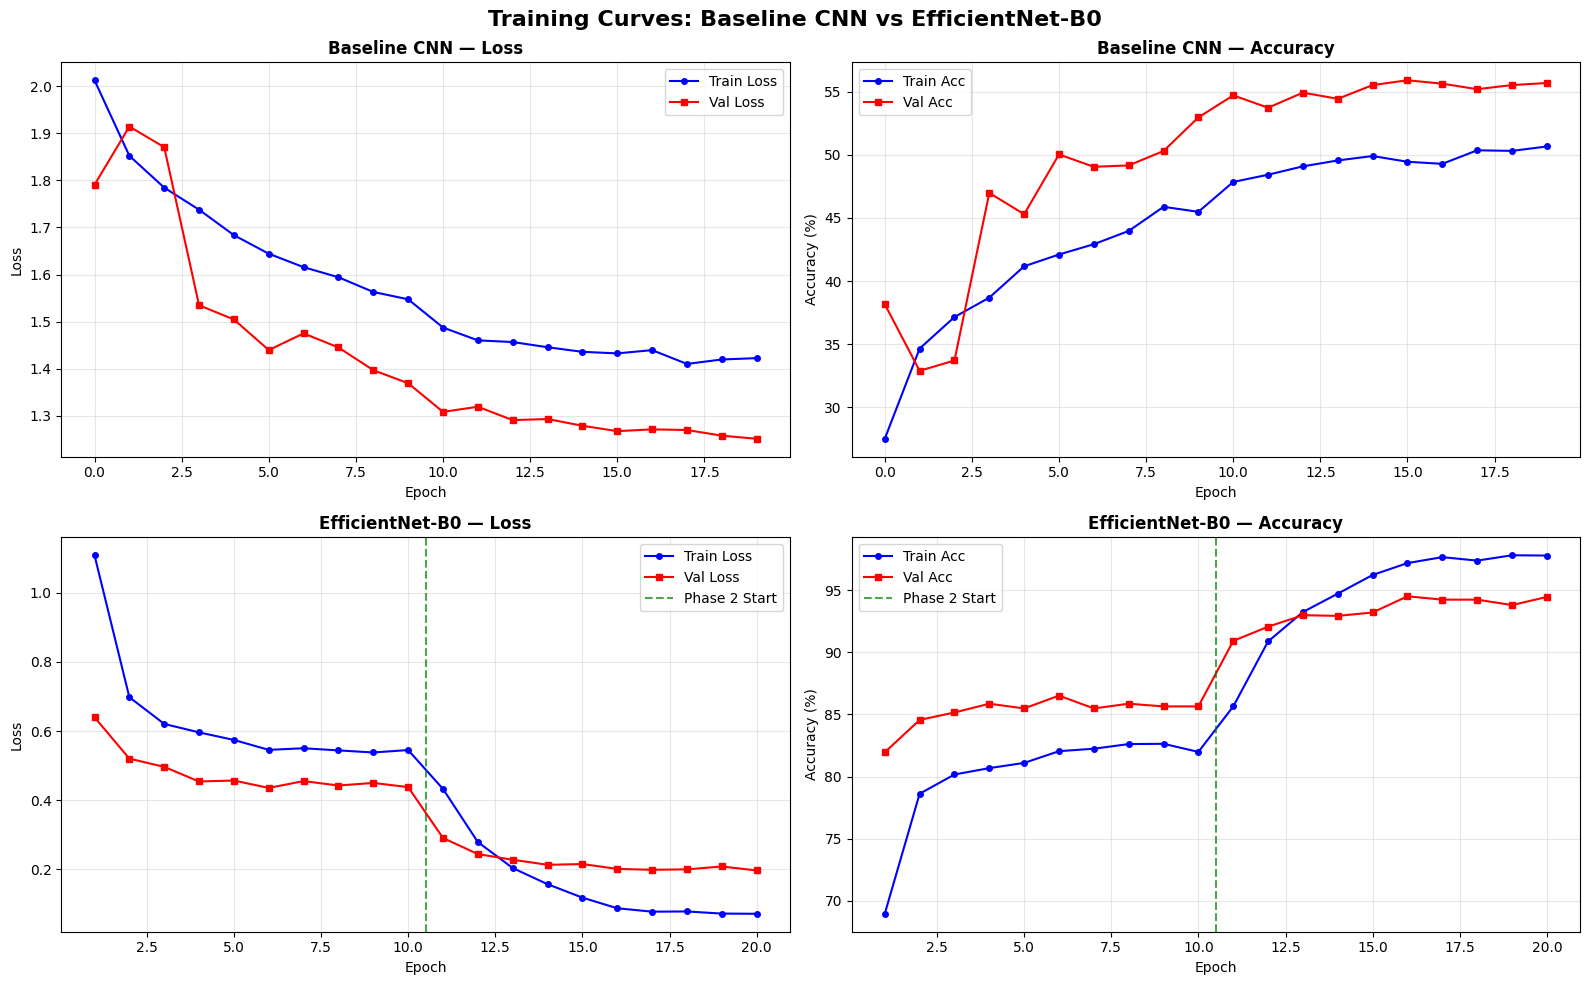

In [12]:
# ===================== TRAINING CURVES =====================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Curves: Baseline CNN vs EfficientNet-B0',
             fontsize=16, fontweight='bold')

# --- Baseline CNN Loss ---
ax = axes[0, 0]
ax.plot(history_cnn['train_loss'], 'b-o', markersize=4, label='Train Loss')
ax.plot(history_cnn['val_loss'],   'r-s', markersize=4, label='Val Loss')
ax.set_title('Baseline CNN — Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Baseline CNN Accuracy ---
ax = axes[0, 1]
ax.plot(history_cnn['train_acc'], 'b-o', markersize=4, label='Train Acc')
ax.plot(history_cnn['val_acc'],   'r-s', markersize=4, label='Val Acc')
ax.set_title('Baseline CNN — Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)

# --- EfficientNet Loss ---
ax = axes[1, 0]
epochs_eff = range(1, len(history_eff['train_loss'])+1)
ax.plot(epochs_eff, history_eff['train_loss'], 'b-o', markersize=4, label='Train Loss')
ax.plot(epochs_eff, history_eff['val_loss'],   'r-s', markersize=4, label='Val Loss')
ax.axvline(x=10.5, color='green', linestyle='--', alpha=0.7, label='Phase 2 Start')
ax.set_title('EfficientNet-B0 — Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# --- EfficientNet Accuracy ---
ax = axes[1, 1]
ax.plot(epochs_eff, history_eff['train_acc'], 'b-o', markersize=4, label='Train Acc')
ax.plot(epochs_eff, history_eff['val_acc'],   'r-s', markersize=4, label='Val Acc')
ax.axvline(x=10.5, color='green', linestyle='--', alpha=0.7, label='Phase 2 Start')
ax.set_title('EfficientNet-B0 — Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Test Set Evaluation

In [13]:
# ===================== TEST SET EVALUATION =====================
print("=" * 60)
print("  BASELINE CNN — Test Results")
print("=" * 60)
preds_cnn, labels_cnn, imgs_cnn, metrics_cnn = evaluate_model(
    baseline_cnn, test_loader, class_names, device)

print("\n" + "=" * 60)
print("  EFFICIENTNET-B0 — Test Results")
print("=" * 60)
preds_eff, labels_eff, imgs_eff, metrics_eff = evaluate_model(
    efficientnet, test_loader, class_names, device)

  BASELINE CNN — Test Results
  Accuracy:  59.11%
  Precision: 58.78%
  Recall:    59.11%
  F1-Score:  57.82%

              precision    recall  f1-score   support

     battery       0.76      0.62      0.68       113
  biological       0.66      0.84      0.74       105
   cardboard       0.65      0.74      0.69       211
     clothes       0.59      0.86      0.70       284
       glass       0.60      0.63      0.61       261
       metal       0.47      0.25      0.33       140
       paper       0.51      0.47      0.49       200
     plastic       0.53      0.46      0.49       240
       shoes       0.55      0.46      0.50       217
       trash       0.78      0.37      0.50        68

    accuracy                           0.59      1839
   macro avg       0.61      0.57      0.57      1839
weighted avg       0.59      0.59      0.58      1839


  EFFICIENTNET-B0 — Test Results
  Accuracy:  93.80%
  Precision: 93.80%
  Recall:    93.80%
  F1-Score:  93.78%

              p

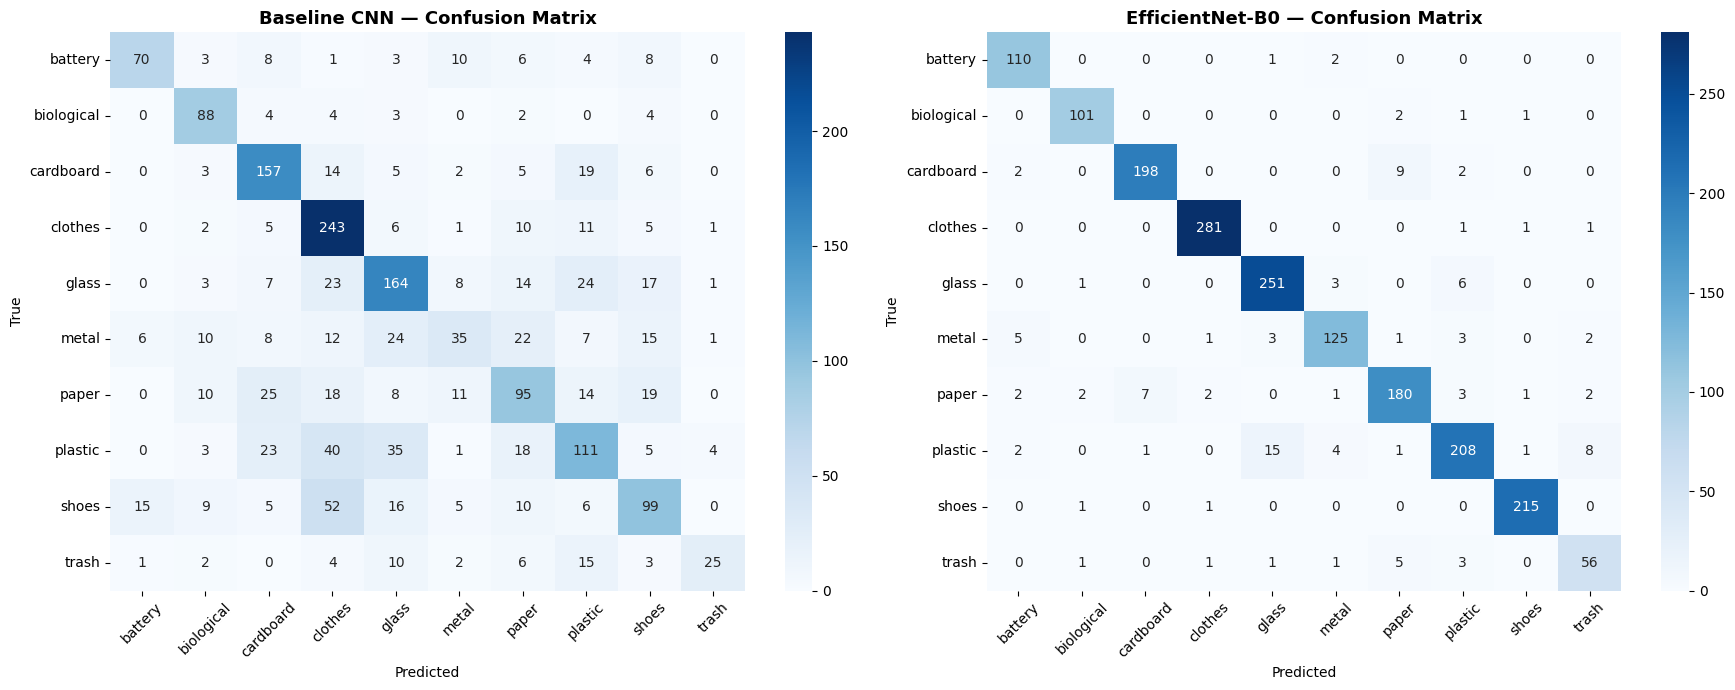

In [14]:
# ===================== CONFUSION MATRICES =====================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, preds, labels, title in [
    (axes[0], preds_cnn, labels_cnn, 'Baseline CNN'),
    (axes[1], preds_eff, labels_eff, 'EfficientNet-B0')
]:
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{title} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

---
## 6. Error Analysis

Baseline CNN misclassifications:


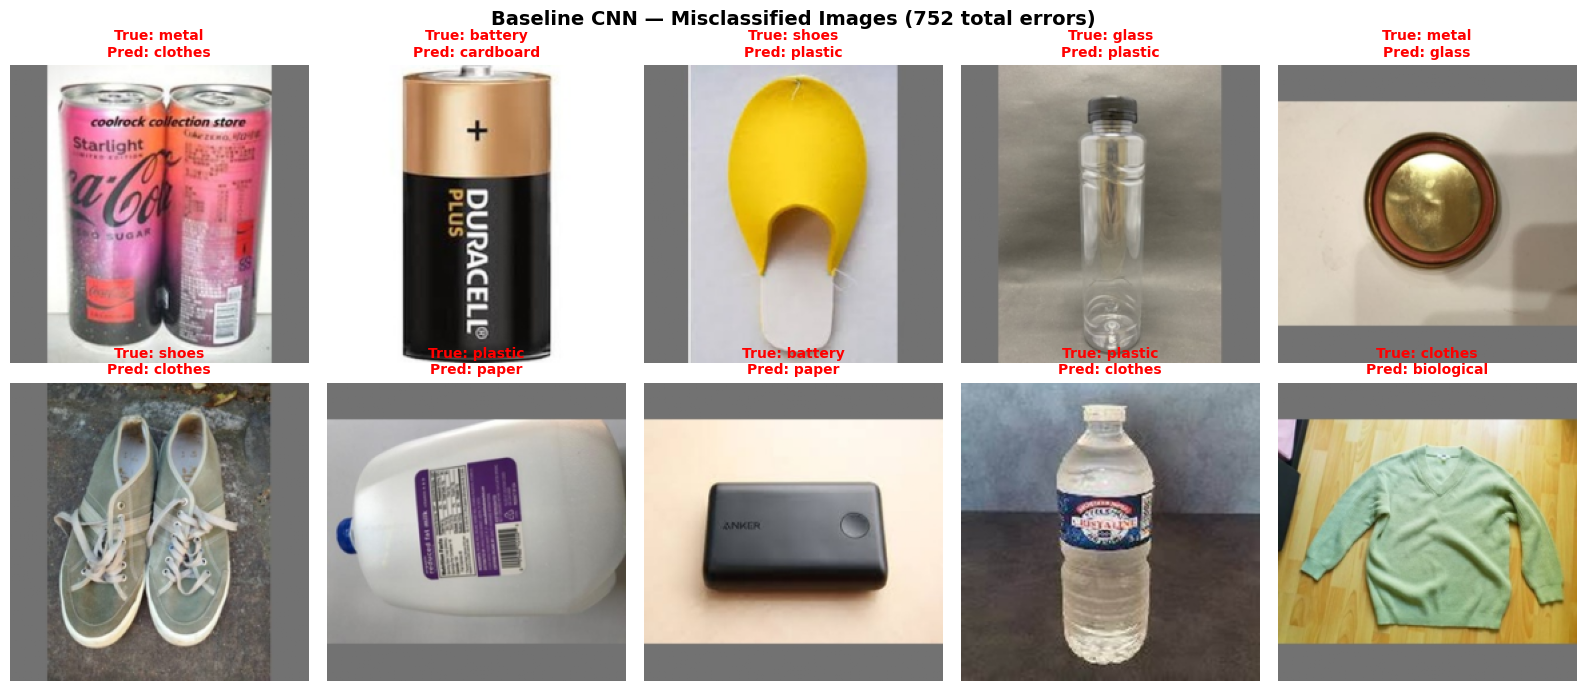


EfficientNet-B0 misclassifications:


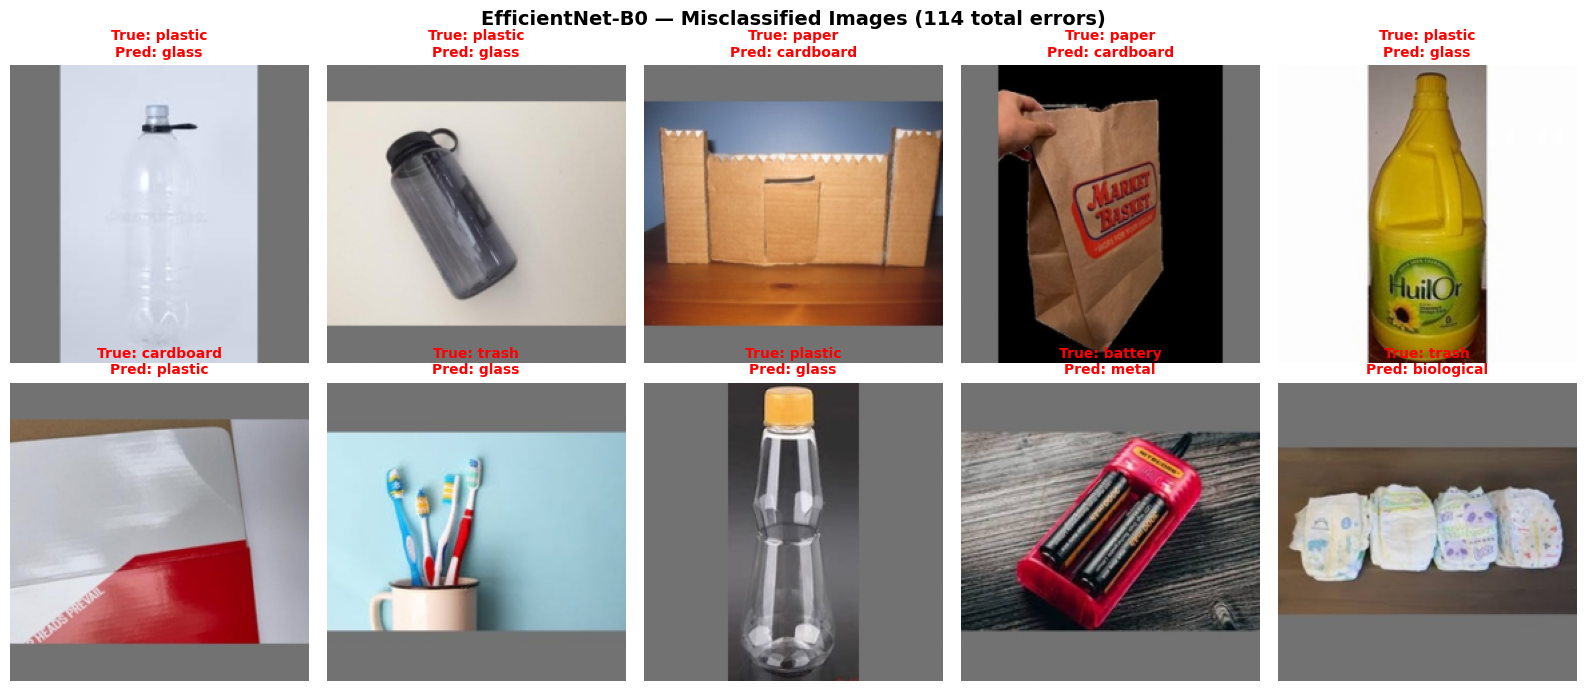

In [15]:
# ===================== ERROR ANALYSIS =====================
def show_misclassified(images, true_labels, pred_labels, class_names,
                       model_name, n=10):
    """Display misclassified images with predicted vs true labels."""
    wrong_idx = np.where(true_labels != pred_labels)[0]
    n = min(n, len(wrong_idx))
    if n == 0:
        print(f"No misclassifications for {model_name}!")
        return
    chosen = np.random.choice(wrong_idx, n, replace=False)

    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.5))
    fig.suptitle(f'{model_name} — Misclassified Images ({len(wrong_idx)} total errors)',
                 fontsize=14, fontweight='bold')

    if rows == 1:
        axes = axes.reshape(1, -1)

    for i, idx in enumerate(chosen):
        r, c = divmod(i, cols)
        img = denormalize(images[idx])
        axes[r, c].imshow(img.permute(1, 2, 0).numpy())
        axes[r, c].set_title(
            f"True: {class_names[true_labels[idx]]}\n"
            f"Pred: {class_names[pred_labels[idx]]}",
            fontsize=10, color='red', fontweight='bold')
        axes[r, c].axis('off')

    # Hide unused axes
    for i in range(n, rows * cols):
        r, c = divmod(i, cols)
        axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()

np.random.seed(42)
print("Baseline CNN misclassifications:")
show_misclassified(imgs_cnn, labels_cnn, preds_cnn, class_names, 'Baseline CNN', n=10)

print("\nEfficientNet-B0 misclassifications:")
show_misclassified(imgs_eff, labels_eff, preds_eff, class_names, 'EfficientNet-B0', n=10)

---
## 7. Model Comparison

In [16]:
# ===================== COMPARISON TABLE =====================
import pandas as pd

comparison = pd.DataFrame({
    'Metric': ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)',
               'Total Parameters', 'Training Epochs'],
    'Baseline CNN': [
        f"{metrics_cnn['accuracy']:.2f}",
        f"{metrics_cnn['precision']:.2f}",
        f"{metrics_cnn['recall']:.2f}",
        f"{metrics_cnn['f1_score']:.2f}",
        f"{sum(p.numel() for p in baseline_cnn.parameters()):,}",
        '20'
    ],
    'EfficientNet-B0': [
        f"{metrics_eff['accuracy']:.2f}",
        f"{metrics_eff['precision']:.2f}",
        f"{metrics_eff['recall']:.2f}",
        f"{metrics_eff['f1_score']:.2f}",
        f"{sum(p.numel() for p in efficientnet.parameters()):,}",
        '10 + 10 (fine-tune)'
    ]
})

print("=" * 60)
print("  MODEL COMPARISON SUMMARY")
print("=" * 60)
print(comparison.to_string(index=False))

# Determine winner
if metrics_eff['f1_score'] > metrics_cnn['f1_score']:
    diff = metrics_eff['f1_score'] - metrics_cnn['f1_score']
    winner = "EfficientNet-B0"
else:
    diff = metrics_cnn['f1_score'] - metrics_eff['f1_score']
    winner = "Baseline CNN"

print(f"\n>> Winner: {winner} (F1 advantage: +{diff:.2f}%)")
print(f"\nConclusion: {winner} performs better on the waste classification task.")
if winner == "EfficientNet-B0":
    print("Transfer learning with EfficientNet-B0 leverages pretrained ImageNet")
    print("features, enabling better generalization even with limited training data.")
else:
    print("The custom Baseline CNN surprisingly outperforms EfficientNet-B0,")
    print("possibly due to the specific dataset characteristics.")

  MODEL COMPARISON SUMMARY
          Metric Baseline CNN     EfficientNet-B0
    Accuracy (%)        59.11               93.80
   Precision (%)        58.78               93.80
      Recall (%)        59.11               93.80
    F1-Score (%)        57.82               93.78
Total Parameters      129,290           4,020,358
 Training Epochs           20 10 + 10 (fine-tune)

>> Winner: EfficientNet-B0 (F1 advantage: +35.96%)

Conclusion: EfficientNet-B0 performs better on the waste classification task.
Transfer learning with EfficientNet-B0 leverages pretrained ImageNet
features, enabling better generalization even with limited training data.


In [ ]:
# ===================== SAVE MODEL =====================
import torch
print("Saving EfficientNet-B0 model weights...")
torch.save(efficientnet.state_dict(), 'efficientnet_b0_weights.pth')
print("Model saved to efficientnet_b0_weights.pth")
